<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Валерий! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Комментарий студента</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

<span style="color: blue; font-size: 18px; font-weight: bold;">Комментарий ревьюера 2</span>

<span style="color: blue">Привет еще раз. Спасибо, за исправления. Оформление комментариев по работе сохраняется. Только обозначим, что это вторая итерация.</span>

# Сборный проект - 2

### Описание проекта

**Описание проекта:**  
Разработка ML-моделей для HR-аналитики компании «Работа с заботой» с целью прогнозирования уровня удовлетворённости сотрудников и риска их увольнения. Это позволит бизнесу минимизировать финансовые потери и управлять оттоком персонала.  

**Задачи:**  
1. **Прогнозирование удовлетворённости работой:**  
   - Построить модель, предсказывающую уровень удовлетворённости (0–1) на основе данных о сотрудниках.  
   - Снизить зависимость от ручного сбора данных через опросники.  

2. **Прогнозирование оттока сотрудников:**  
   - Создать модель для определения риска увольнения.  
   - Выявить ключевые факторы, влияющие на решение сотрудников уйти.  

**Цель для бизнеса:**  
Предотвратить внезапные увольнения, особенно ключевых специалистов, через анализ взаимосвязи удовлетворённости и оттока.

### Описание данных


В таблицах данные обозначены:
+ `id` — уникальный идентификатор сотрудника;
+ `dept` — отдел, в котором работает сотрудник;
+ `level` — уровень занимаемой должности;
+ `workload` — уровень загруженности сотрудника;
+ `employment_years` — длительность работы в компании (в годах);
+ `last_year_promo` — показывает, было ли повышение за последний год;
+ `last_year_violations` — показывает, нарушал ли сотрудник трудовой договор за последний год;
+ `supervisor_evaluation` — оценка качества работы сотрудника, которую дал руководитель;
+ `salary` — ежемесячная зарплата сотрудника;
+ `job_satisfaction_rate` — уровень удовлетворённости сотрудника работой в компании, целевой признак.



# Задача 1: Предсказание уровня удовлетворённости сотрудника

### Установка пакетов.

In [1]:
!pip install phik -q

In [2]:
!pip install --upgrade scikit-learn==1.3.0 -q

In [3]:
!pip install shap -q

### Импорт библиотек

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas  as pd

import phik
import seaborn as sns
import shap
import warnings


from sklearn.dummy import (DummyClassifier, 
                           DummyRegressor)
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.metrics import (make_scorer, 
                             roc_auc_score)
from sklearn.model_selection import (RandomizedSearchCV,
                                     GridSearchCV)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (LabelEncoder,
                                   OneHotEncoder, 
                                   OrdinalEncoder,
                                   MinMaxScaler,
                                   RobustScaler,
                                   StandardScaler
                                  )

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from scipy. stats import ttest_ind

# настройки отображения таблиц
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

warnings.simplefilter(action='ignore', category=FutureWarning)


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Импорты собраны в одной ячейке, разделены на функциональные группы пустой строкой.</font>

### Определение функций

#### `print_unique_categorical_values`

Функция выводит уникальные значения для всех категориальных столбцов. Метод определяет, что колонка категориальная по типу данных `object`

In [5]:
def print_unique_categorical_values(df):
    
    categorical_columns = df.select_dtypes(include='object').columns #выбираем колонки по типу `object`
    if len(categorical_columns) == 0: # Проверяем, есть ли категориальные колонки
        print("В датафрейме нет категориальных столбцов.")
        return
    for column in categorical_columns: # Проходим по каждой категориальной колонке и выводим уникальные значения
        unique_values = df[column].unique()
        print(f"Уникальные значения в колонке '{column}':")
        print(unique_values)
        print("-" * 50)  # Разделитель для удобства чтения

#### `f_hist_box`

Функция для вывода гистограммы и ящика с усами по двум выборкам.

In [6]:
def f_hist_box(train, test, bins, range, title, xlabel, ylabel):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, figsize=(10,5), gridspec_kw={"height_ratios": (.15, .85)})
     
    sns.boxplot(data=[train, test], orient="h", ax=ax_box)
    plt.hist([train, test], 
             bins=bins, range=range, label=['train', 'test'])
 
    plt.legend(loc='upper right')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

#### `f_countplot`

Функция для вывода графика подсчета по двум выборкам.

In [7]:
def f_countplot(train, test, suptitle, xlabel, ylabel):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))
    fig.tight_layout(h_pad=3)
    fig.suptitle(suptitle, x=0.5, y=1.07, fontsize=16)
    
    sns.countplot(x=train,ax=ax1)
    sns.countplot(x=test,ax=ax2)
    
    ax1.set_title('График подсчета для тренировочной выборки')
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    
    ax2.set_title('График подсчета для тестовой выборки')
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(ylabel)

#### `f_pie_x2`

Функция для вывода круговых диаграмм по двум выборкам

In [8]:
def f_pie_x2(train, test, col, suptitle):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))
    fig.suptitle(suptitle, x=0.5, y=0.75, fontsize=12)
    
    (
    train
        .pivot_table(index=col,values='id',aggfunc='count')
        .plot.pie(y='id', autopct='%1.0f%%', figsize=(10,10), ax=ax1, 
                  label='Доля')
    )
    (
    test
        .pivot_table(index=col,values='id',aggfunc='count')
        .plot.pie(y='id', autopct='%1.0f%%', figsize=(10,10), ax=ax2, 
                  label='Доля')
    )
    ax1.set_title('train')
    ax2.set_title('test')
    plt.tight_layout()
    plt.show()

## Загрузка данных

Прочитаем все датасеты и сохраним в датафреймы.

In [9]:
try:
    train_job_satisfaction_rate = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')
    test_features = pd.read_csv('/datasets/test_features.csv')
    test_target_job_satisfaction_rate = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')
    
except Exception:
    train_job_satisfaction_rate = pd.read_csv('train_job_satisfaction_rate.csv')
    test_features = pd.read_csv('test_features.csv')
    test_target_job_satisfaction_rate = pd.read_csv('test_target_job_satisfaction_rate.csv')

Выведем первые 5 строк и информацию о датасете тренировочной выборки.

In [10]:
display(train_job_satisfaction_rate.head())
train_job_satisfaction_rate.info()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


Мы видим несколько нулевых значений, а также, что тренировочная выборка должна содержать 4000 примеров объектов.

Выведем 5 строк и информацию о входных признаках тестовой выборки.

In [11]:
display(test_features.head())
test_features.info()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


Мы также видим пару пропусков и количество значений.

Целевой признак тестовой выборки.

In [12]:
display(test_target_job_satisfaction_rate.head())
test_target_job_satisfaction_rate.info()

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


В данных целевого признака уже нет пропусков.

Данные прочитаны. Переходим к предобработке.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Данные загружены корректно, первичный осмотр проведен.</font>

## Предобработка данных

### Проверка типов данных

В датасетах столбцы со следующими данными:
+ `id` — уникальный идентификатор сотрудника;
+ `dept` — отдел, в котором работает сотрудник;
+ `level` — уровень занимаемой должности;
+ `workload` — уровень загруженности сотрудника;
+ `employment_years` — длительность работы в компании (в годах);
+ `last_year_promo` — показывает, было ли повышение за последний год;
+ `last_year_violations` — показывает, нарушал ли сотрудник трудовой договор за последний год;
+ `supervisor_evaluation` — оценка качества работы сотрудника, которую дал руководитель;
+ `salary` — ежемесячная зарплата сотрудника;
+ `job_satisfaction_rate` — уровень удовлетворённости сотрудника работой в компании, целевой признак.


In [13]:
train_job_satisfaction_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


В датасете `train_job_satisfaction_rate` все типы данных указаны верно

In [14]:
test_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


В датасете `test_features` все типы данных указаны верно

In [15]:
test_target_job_satisfaction_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


В датасете `test_target_job_satisfaction_rate` все типы данных указаны верно

### Проверка дубликатов

Проверим данные на наличие дубликатов:

In [16]:
print(f'Количество дубликатов в train_job_satisfaction_rate:{train_job_satisfaction_rate.duplicated().sum()}')

Количество дубликатов в train_job_satisfaction_rate:0


In [17]:
print(f'Количество дубликатов в test_features:{test_features.duplicated().sum()}')

Количество дубликатов в test_features:0


In [18]:
print(f'Количество дубликатов в test_target_job_satisfaction_rate:{test_target_job_satisfaction_rate.duplicated().sum()}')

Количество дубликатов в test_target_job_satisfaction_rate:0


Явных дубликатов в данных не найдено.

Проверим датасеты на неявные дубликаты

In [19]:
print_unique_categorical_values(train_job_satisfaction_rate)

Уникальные значения в колонке 'dept':
['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]
--------------------------------------------------
Уникальные значения в колонке 'level':
['junior' 'middle' 'sinior' nan]
--------------------------------------------------
Уникальные значения в колонке 'workload':
['medium' 'high' 'low']
--------------------------------------------------
Уникальные значения в колонке 'last_year_promo':
['no' 'yes']
--------------------------------------------------
Уникальные значения в колонке 'last_year_violations':
['no' 'yes']
--------------------------------------------------


In [20]:
print_unique_categorical_values(test_target_job_satisfaction_rate)

В датафрейме нет категориальных столбцов.


In [21]:
print_unique_categorical_values(test_features)

Уникальные значения в колонке 'dept':
['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
--------------------------------------------------
Уникальные значения в колонке 'level':
['junior' 'middle' 'sinior' nan]
--------------------------------------------------
Уникальные значения в колонке 'workload':
['medium' 'low' 'high' ' ']
--------------------------------------------------
Уникальные значения в колонке 'last_year_promo':
['no' 'yes']
--------------------------------------------------
Уникальные значения в колонке 'last_year_violations':
['no' 'yes']
--------------------------------------------------


Обработаем значения ` ` в столбцах `workload` и `dept`.
А также исправим написание `sinior`.

In [22]:
# test_features['dept'] = test_features['dept'].replace(' ', np.nan)
# test_features['workload'] = test_features['workload'].replace(' ', np.nan)

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'>  ~~Здорово, что отмечено новое значение в категориях, но такие значения нужно обработать в Пайплайн, инструментами Энкодеров.~~</font>

</span><br><span style="color: purple; font-weight: bold">Обработку значений внутри пайплайна реализовал, забыл убрать код с заменой "вручную"</span>

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

In [23]:
train_job_satisfaction_rate['level'] = train_job_satisfaction_rate['level'].replace('sinior', 'senior')
test_features['level'] = test_features['level'].replace('sinior', 'senior')

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [24]:
print_unique_categorical_values(train_job_satisfaction_rate)

Уникальные значения в колонке 'dept':
['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]
--------------------------------------------------
Уникальные значения в колонке 'level':
['junior' 'middle' 'senior' nan]
--------------------------------------------------
Уникальные значения в колонке 'workload':
['medium' 'high' 'low']
--------------------------------------------------
Уникальные значения в колонке 'last_year_promo':
['no' 'yes']
--------------------------------------------------
Уникальные значения в колонке 'last_year_violations':
['no' 'yes']
--------------------------------------------------


In [25]:
print_unique_categorical_values(test_features)

Уникальные значения в колонке 'dept':
['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
--------------------------------------------------
Уникальные значения в колонке 'level':
['junior' 'middle' 'senior' nan]
--------------------------------------------------
Уникальные значения в колонке 'workload':
['medium' 'low' 'high' ' ']
--------------------------------------------------
Уникальные значения в колонке 'last_year_promo':
['no' 'yes']
--------------------------------------------------
Уникальные значения в колонке 'last_year_violations':
['no' 'yes']
--------------------------------------------------


### Объединение датасетов

Проверка сопоставимости данных в `test_features` и `test_target_job_satisfaction_rate`.

In [26]:
test_job_satisfaction_rate = pd.merge(test_features, test_target_job_satisfaction_rate, on='id', sort=True)
print(test_job_satisfaction_rate.info())
test_job_satisfaction_rate.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   dept                   1998 non-null   object 
 2   level                  1999 non-null   object 
 3   workload               2000 non-null   object 
 4   employment_years       2000 non-null   int64  
 5   last_year_promo        2000 non-null   object 
 6   last_year_violations   2000 non-null   object 
 7   supervisor_evaluation  2000 non-null   int64  
 8   salary                 2000 non-null   int64  
 9   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 171.9+ KB
None


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,100298,hr,junior,low,2,no,no,4,19200,0.80
1,100480,marketing,junior,low,4,no,no,4,16800,0.84
2,100503,purchasing,middle,high,5,no,no,4,55200,0.79
3,100610,sales,middle,medium,5,no,no,4,43200,0.75
4,100692,sales,middle,high,6,no,no,4,48000,0.69


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Верно, при объединении таблиц нужно привязаться к уникальному `"id"`.</font>

Мы видим, что количество записей до и после объединения одинаковое, значит таблицы объединены верно.

Проверяем все ли колонки соответствуют друг другу в тестовой и тренировочной выборках.

In [27]:
if list(train_job_satisfaction_rate)==list(test_job_satisfaction_rate):
    print('Все колонки совпадают')
else:
    print('Некоторые колонки не совпадают')

Все колонки совпадают


Проверим есть ли совпадение id в тренировочной и тестовой выборках

In [28]:
print('Количество совпадений "id" в выборках: ', len(train_job_satisfaction_rate[train_job_satisfaction_rate['id'].isin(test_features['id'].unique())]))

Количество совпадений "id" в выборках:  0


### Вывод по предобработке данных
+ Во всех столбцах верно указаны типы данных.
+ В данных нет дубликатов.
+ Пропущенные значения приведены к общему виду `np.nan`. Дальнейшее заполнение пропусков будет проведено в пайплайне при обучении модели с использованием `SimpleImputer`.
+ Ошибки в текстовых обозначениях данных исправлены.
+ Датасеты с тестовой выборкой объединены.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️ <br>
<font color='green'>Здорово, что не забываешь про промежуточные выводы.</font>

## Исследовательский анализ данных

### Количественные данные

In [29]:
train_job_satisfaction_rate.describe()

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,"4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,"544,957.62",3.72,3.48,"33,926.70",0.53
std,"257,883.10",2.54,1.01,"14,900.70",0.23
min,"100,954.00",1.00,1.00,"12,000.00",0.03
25%,"322,836.75",2.00,3.00,"22,800.00",0.36
50%,"534,082.50",3.00,4.00,"30,000.00",0.56
75%,"771,446.00",6.00,4.00,"43,200.00",0.71
max,"999,521.00",10.00,5.00,"98,400.00",1.00


In [30]:
test_job_satisfaction_rate.describe()

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,"2,000.00","2,000.00","2,000.00","2,000.00","2,000.00"
mean,"552,765.21",3.67,3.53,"34,066.80",0.55
std,"253,851.33",2.54,1.00,"15,398.44",0.22
min,"100,298.00",1.00,1.00,"12,000.00",0.03
25%,"339,052.00",1.00,3.00,"22,800.00",0.38
50%,"550,793.00",3.00,4.00,"30,000.00",0.58
75%,"765,763.75",6.00,4.00,"43,200.00",0.72
max,"999,029.00",10.00,5.00,"96,000.00",1.00


### Количественные данные. Графики подсчета.

Исследование `employment_years`.

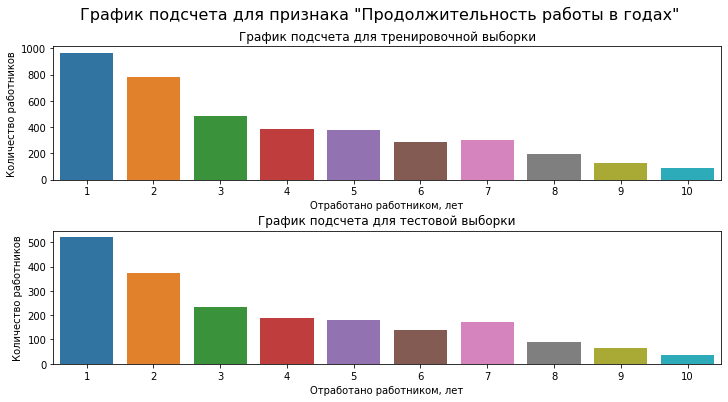

In [31]:
f_countplot(
    train=train_job_satisfaction_rate['employment_years'],
    test=test_job_satisfaction_rate['employment_years'],
    suptitle = 'График подсчета для признака "Продолжительность работы в годах"',
    xlabel='Отработано работником, лет',
    ylabel='Количество работников'
)

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Здорово, что сравниваешь выборки!</font>

Исследование `supervisor_evaluation`.

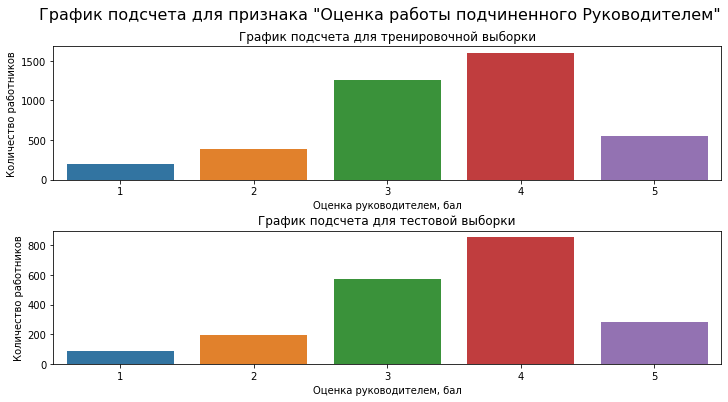

In [32]:
f_countplot(
    train=train_job_satisfaction_rate['supervisor_evaluation'],
    test=test_job_satisfaction_rate['supervisor_evaluation'],
    suptitle = 'График подсчета для признака "Оценка работы подчиненного Руководителем"',
    xlabel='Оценка руководителем, бал',
    ylabel='Количество работников'
)

### Количественные данные. Гистограммы и ящики с усами.

Исследование `salary`.

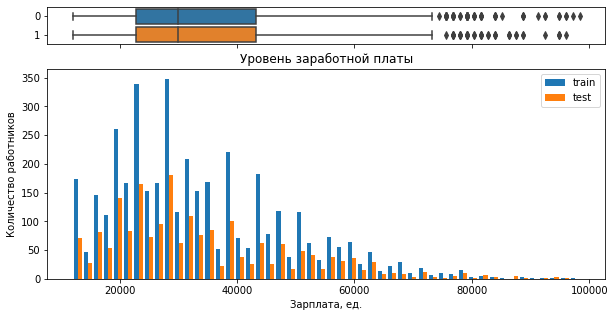

In [33]:
f_hist_box(
    train=train_job_satisfaction_rate['salary'],
    test=test_job_satisfaction_rate['salary'],
    bins=50, 
    range=(train_job_satisfaction_rate['salary'].min(),train_job_satisfaction_rate['salary'].max()),
    title='Уровень заработной платы',
    xlabel='Зарплата, ед.',
    ylabel='Количество работников'
)

Исследование `job_satisfaction_rate`.

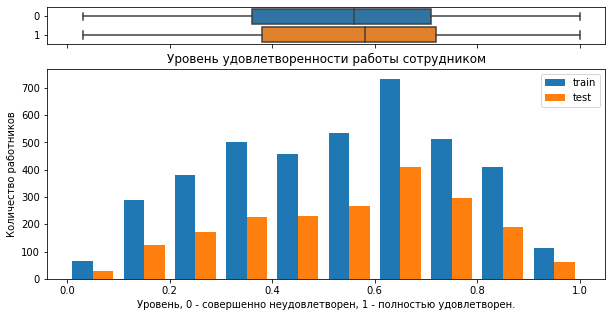

In [34]:
f_hist_box(
    train=train_job_satisfaction_rate['job_satisfaction_rate'],
    test=test_job_satisfaction_rate['job_satisfaction_rate'],
    bins=10, 
    range=(0,1),
    title='Уровень удовлетворенности работы сотрудником',
    xlabel='Уровень, 0 - совершенно неудовлетворен, 1 - полностью удовлетворен.',
    ylabel='Количество работников'
)

### Качестсвенные данные

Рассмотрим качественные данные.

In [35]:
train_job_satisfaction_rate.describe(include='object')

,dept,level,workload,last_year_promo,last_year_violations
count,3994,3996,4000,4000,4000
unique,5,3,3,2,2
top,sales,junior,medium,no,no
freq,1512,1894,2066,3880,3441


In [36]:
test_job_satisfaction_rate.describe(include='object')

,dept,level,workload,last_year_promo,last_year_violations
count,1998,1999,2000,2000,2000
unique,6,3,4,2,2
top,sales,junior,medium,no,no
freq,763,974,1043,1937,1738


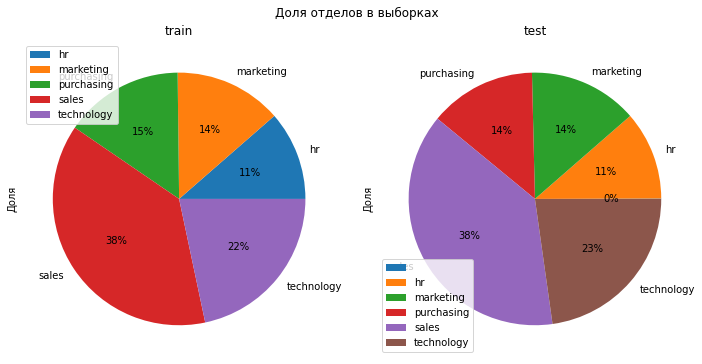

In [37]:
f_pie_x2(train=train_job_satisfaction_rate,
         test=test_job_satisfaction_rate,
         col='dept',
         suptitle='Доля отделов в выборках'
)

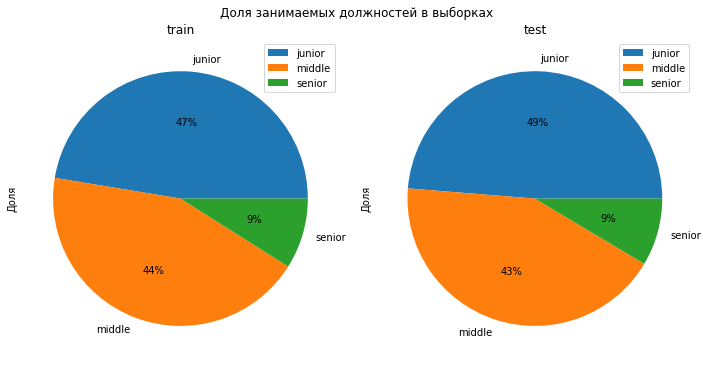

In [38]:
f_pie_x2(train=train_job_satisfaction_rate,
         test=test_job_satisfaction_rate,
         col='level',
         suptitle='Доля занимаемых должностей в выборках'
)

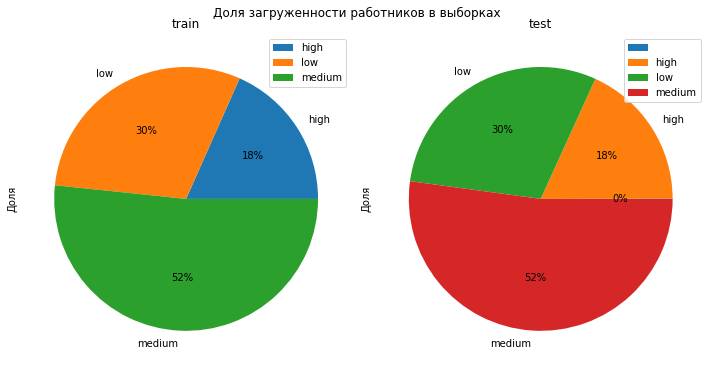

In [39]:
f_pie_x2(train=train_job_satisfaction_rate,
         test=test_job_satisfaction_rate,
         col='workload',
         suptitle='Доля загруженности работников в выборках'
)

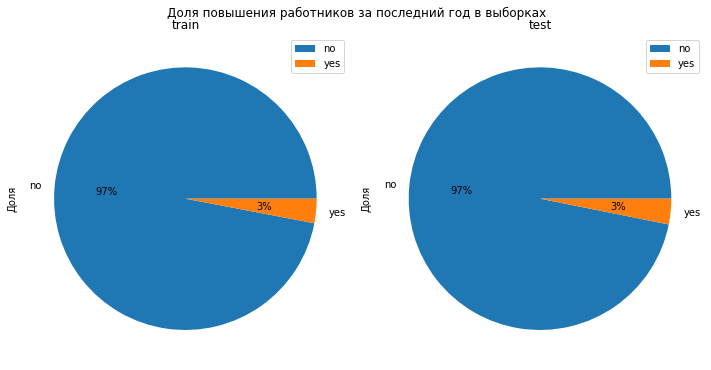

In [40]:
f_pie_x2(train=train_job_satisfaction_rate,
         test=test_job_satisfaction_rate,
         col='last_year_promo',
         suptitle='Доля повышения работников за последний год в выборках'
)

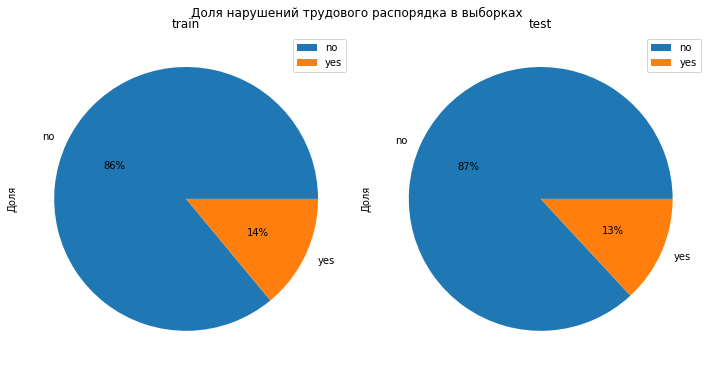

In [41]:
f_pie_x2(train=train_job_satisfaction_rate,
         test=test_job_satisfaction_rate,
         col='last_year_violations',
         suptitle='Доля нарушений трудового распорядка в выборках'
)

### Корреляционный анализ

Сделаем столбец `id` индексным.

In [42]:
train_job_satisfaction_rate = train_job_satisfaction_rate.sort_values(by=['id']).set_index('id')
test_job_satisfaction_rate = test_job_satisfaction_rate.sort_values(by=['id']).set_index('id')

<font color='blue'><b>Комментарий ревьюера: </b></font> ⚠️\
<font color='darkorange'>Так как мы удалили признак "id" с неповторяющимися значениями, у нас могут появиться новые явные дубликаты: чем меньше признаков остаётся, тем выше шанс, что значения остальных признаков будут пересекаться. При этом ценности для модели такие наблюдения уже не принесут, поэтому стоит проверить дубликаты также в финальной версии обучающей таблицы.</font>

Проведем исследование корреляций признаков для исключения мультиколлинеарности.

Для начала создадим список interval_cols, который содержит названия столбцов с непрерывными числовыми признаками.

In [43]:
interval_cols = ['salary', 'job_satisfaction_rate']

Построим матрицы корреляций для тренировочной и тестовой выборок.

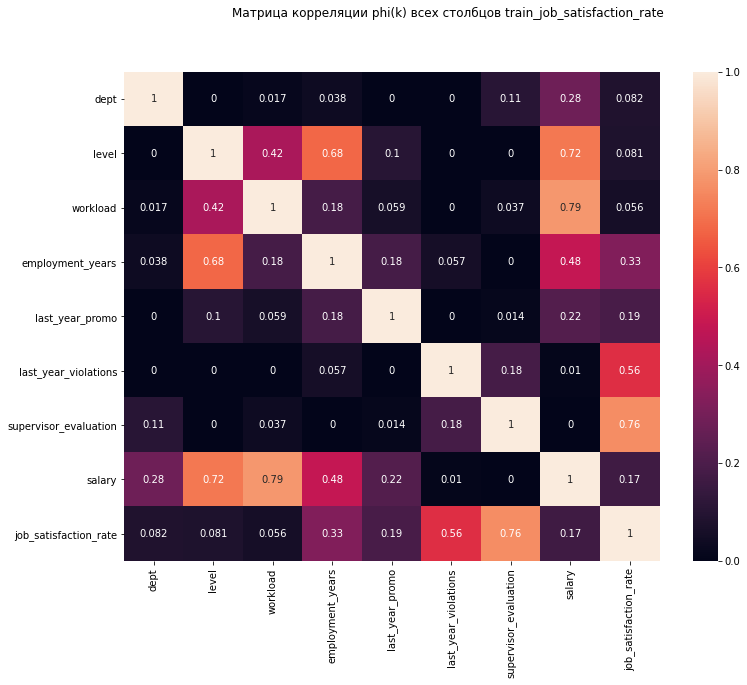

In [44]:
fig, ax = plt.subplots(figsize=(12, 9))
plt.suptitle('Матрица корреляции phi(k) всех столбцов train_job_satisfaction_rate')
sns.heatmap(train_job_satisfaction_rate.phik_matrix(interval_cols=interval_cols), annot=True);

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'>Здорово,что применена `phik` для анализа и нелинейных зависимостей</font>

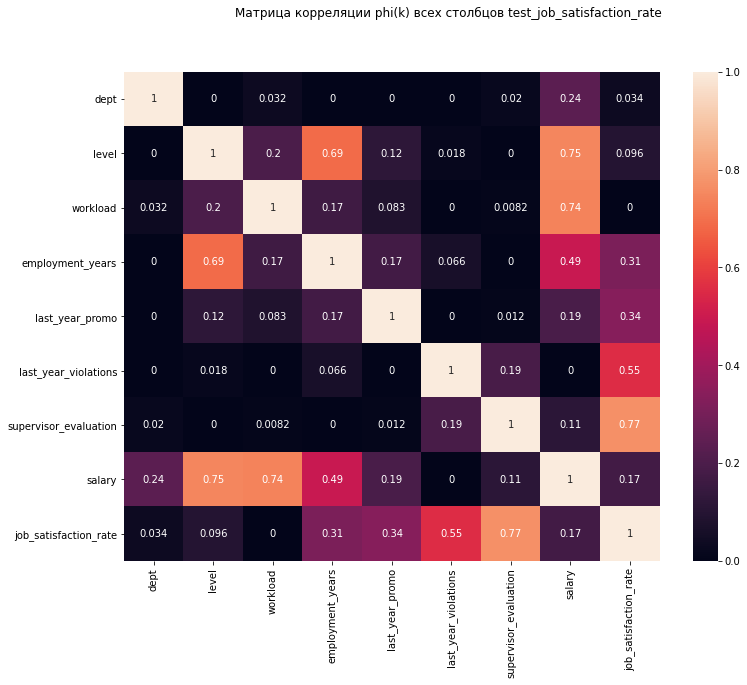

In [45]:
fig, ax = plt.subplots(figsize=(12, 9))
plt.suptitle('Матрица корреляции phi(k) всех столбцов test_job_satisfaction_rate')
sns.heatmap(test_job_satisfaction_rate.phik_matrix(interval_cols=interval_cols), annot=True);

### Вывод по исследовательскому анализу данных

**Вывод по анализу данных**

+ `employment_years` - Количество работников убывает с течением лет. Примерно одинково для тестовой и тренировочной выборок
+ `supervisor_evaluation` -  Большая часть работников получае оценку 4. Графики для обучающей и тестовой выборке примерно совпдают
+ `salary` - Зарплаты имеют пик в районе 30000, после чего идут на снижение. Графики для тестовой и тренировочной выборки примерно совпадают.
+ `job_satisfaction_rate` - Целевой признак, уровень удовлетворенности сотрудника. Графики для тестовйо и тренировочной выборки примерно совпадают.
+ `dept` - Отделы, в окторых работают сотрудники. Доли совпадают для тестовой и тренировочной выборок.
+ `level` - Доля занимаемых должностей в выборках, значения в обучающей и тестовой выборке примерно совпадают.
+ `workload` - Доля загруженности работников в выборках, значения в обучающей и тестовой выборке примерно соответствуют друг другу.
+ `last_year_promo` - Доля повышений работников за год. Значения в обучающей и тестовой выборке примерно совпадают.
+ `last_year_violations` - Доля нарушений трудового распорядка в выборках. Значения в обучающей и тестовой выборке примерно соответствуют друг другу.

**Вывод по корреляционному анализу**
+ Данные `id`, переведены в индекс.
+ Между входными параметрами отсутствует связь выше 0,9 следовательно при обучении модели учитывать мультиколлинеарность не надо. 
+ На тренировочной и тестовой выборках, значения корреляции немного разнятся, но общая оценка соответствуют друг другу.
+ В колонках `dept`, `level`, `workload` необходимо заменить пропуски.
+ Три признака: `dept`, `last_year_promo`, `last_year_violations` — нужно кодировать с помощью OneHotEncoder.
+ Два признака: `level`, `workload` — нужно кодировать с помощью OrdinalEncoder.
+ Три признака: `employment_years`, `supervisor_evaluation`, `salary` - достаточно масштабировать.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Хорошая работа в части исследования данных: молодец, что используешь функции, а также применяешь подходящие для типов данных инструменты.</font>

## Подготовка данных

In [46]:
RANDOM_STATE = 42

X_train_1 = train_job_satisfaction_rate.drop('job_satisfaction_rate', axis=1)
y_train_1 = train_job_satisfaction_rate['job_satisfaction_rate'] 
X_test_1 = test_job_satisfaction_rate.drop('job_satisfaction_rate', axis=1)
y_test_1 = test_job_satisfaction_rate['job_satisfaction_rate']

ohe_columns = ['dept', 'last_year_promo', 'last_year_violations'] 
ord_columns = ['level', 'workload']
num_columns = ['employment_years', 'supervisor_evaluation', 'salary']

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Отлично, что разделяешь категории на порядковые и номинальные.</font>

In [47]:
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False))
    ]
)

In [48]:
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'senior'], 
                    ['low', 'medium', 'high']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),

    ]
)

data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', RobustScaler(), num_columns)
    ], 
    remainder='passthrough'
)

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LinearRegression())
])

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Здорово, что есть обработка неизвестых категорий (можно не удалять `'_'` вручную из тестовых данных.)</font>

In [49]:
X_train_1_transformed = pd.DataFrame(data_preprocessor.fit_transform(X_train_1), columns=data_preprocessor.get_feature_names_out())
X_test_1_transformed = pd.DataFrame(data_preprocessor.transform(X_test_1), columns=data_preprocessor.get_feature_names_out())

X_train_1_transformed.info(), X_test_1_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ohe__dept_marketing            4000 non-null   float64
 1   ohe__dept_purchasing           4000 non-null   float64
 2   ohe__dept_sales                4000 non-null   float64
 3   ohe__dept_technology           4000 non-null   float64
 4   ohe__last_year_promo_yes       4000 non-null   float64
 5   ohe__last_year_violations_yes  4000 non-null   float64
 6   ord__level                     4000 non-null   float64
 7   ord__workload                  4000 non-null   float64
 8   num__employment_years          4000 non-null   float64
 9   num__supervisor_evaluation     4000 non-null   float64
 10  num__salary                    4000 non-null   float64
dtypes: float64(11)
memory usage: 343.9 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:227: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


(None, None)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ⚠️\
<span style="color: darkorange"> Зачем нам трансформированные выборки?</span>

### Вывод по подготовке данных
+ Подготовили данные для обучения в пайплайне.
+ Пропуски в данных заполнены.
+ Кодировали качественные признаки при помощи OneHotEncoder и OrdinalEncoder.
+ Масштабировали данные.

## Обучение моделей

В инструкции нам передана целевая функция `smape`, определим функцию по следующей формуле
$$
SMAPE = \frac{100}{n} \sum^n_{i=1}{\frac{|y_i - \hat{y}_i|}{(|y_i| + |\hat{y}_i|)/2}} 
$$

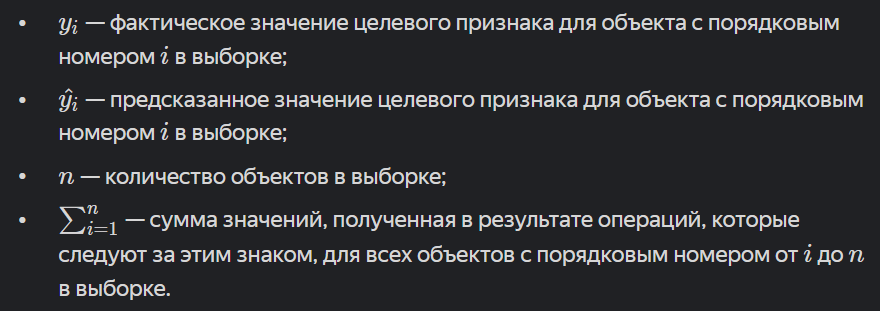

In [50]:
def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum( np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred))/2) ) 
   
smape_scorer = make_scorer(score_func=smape, greater_is_better=False)

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> `smape` расчитана верно.</font>

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️ <br>
<font color='green'>Верно, что не забываешь указать greater_is_better=False, Это пригодится для SearchCV. SMAPE — ошибка, её минимизируем.</font>

In [51]:
param_grid = [

    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']   
    },

    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': [None] + [i for i in range(2, 7)],
        'models__max_features': range(2, 15),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    }
]

In [52]:
rs = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring=smape_scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rs.fit(X_train_1, y_train_1)
print('Лучшая модель и её параметры:\n\n', rs.best_estimator_)
print ('Метрика лучшей модели на кросс-валидации:', rs.best_score_*(-1))

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                   

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'>Подбор гиперпараметров проведён верно. Использована целевая метрика, направление отбора верное ).</font>

In [53]:
print(f'SMAPE лучшей модели на тестовой выборке: {round(smape(y_test_1, rs.predict(X_test_1)),4)}')

SMAPE лучшей модели на тестовой выборке: 14.928


/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:227: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Тестирование проведено верно.</font>

Выведем название лучшей модели и ее параметры.

In [54]:
all_model_1 = pd.DataFrame(rs.cv_results_).sort_values(by=['rank_test_score'])
all_model_1[['rank_test_score',
    'param_models',
    'params'
]].head(10)

,rank_test_score,param_models,params
1,1,"DecisionTreeRegressor(max_features=9, random_state=42)","{'preprocessor__num': MinMaxScaler(), 'models__max_features': 9, 'models__max_depth': None, 'models': DecisionTreeRegressor(max_features=9, random_state=42)}"
6,2,"DecisionTreeRegressor(max_features=9, random_state=42)","{'preprocessor__num': MinMaxScaler(), 'models__max_features': 7, 'models__max_depth': None, 'models': DecisionTreeRegressor(max_features=9, random_state=42)}"
7,3,"DecisionTreeRegressor(max_features=9, random_state=42)","{'preprocessor__num': MinMaxScaler(), 'models__max_features': 3, 'models__max_depth': None, 'models': DecisionTreeRegressor(max_features=9, random_state=42)}"
5,4,"DecisionTreeRegressor(max_features=9, random_state=42)","{'preprocessor__num': RobustScaler(), 'models__max_features': 14, 'models__max_depth': 5, 'models': DecisionTreeRegressor(max_features=9, random_state=42)}"
0,5,"DecisionTreeRegressor(max_features=9, random_state=42)","{'preprocessor__num': MinMaxScaler(), 'models__max_features': 5, 'models__max_depth': 4, 'models': DecisionTreeRegressor(max_features=9, random_state=42)}"
2,6,"DecisionTreeRegressor(max_features=9, random_state=42)","{'preprocessor__num': MinMaxScaler(), 'models__max_features': 3, 'models__max_depth': 4, 'models': DecisionTreeRegressor(max_features=9, random_state=42)}"
4,7,"DecisionTreeRegressor(max_features=9, random_state=42)","{'preprocessor__num': MinMaxScaler(), 'models__max_features': 11, 'models__max_depth': 2, 'models': DecisionTreeRegressor(max_features=9, random_state=42)}"
8,8,"DecisionTreeRegressor(max_features=9, random_state=42)","{'preprocessor__num': 'passthrough', 'models__max_features': 3, 'models__max_depth': 2, 'models': DecisionTreeRegressor(max_features=9, random_state=42)}"
3,9,"DecisionTreeRegressor(max_features=9, random_state=42)","{'preprocessor__num': RobustScaler(), 'models__max_features': 7, 'models__max_depth': 2, 'models': DecisionTreeRegressor(max_features=9, random_state=42)}"
9,10,"DecisionTreeRegressor(max_features=9, random_state=42)","{'preprocessor__num': RobustScaler(), 'models__max_features': 8, 'models__max_depth': 2, 'models': DecisionTreeRegressor(max_features=9, random_state=42)}"


<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> ~~Нужно вывести результаты оценки Топ-10 лучших моделей, для анализа.~~</font>

</span><br><span style="color: purple; font-weight: bold">Вывел 10 лучших моделей. Все из них это DecisionTreeRegressor с разными параметрами.</span>

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> Отлично, что есть табличка результатов для сравнения. Можно отслеживать как изменения гиперпараметров влияют на качество модели.</font>

### Вывод по обучению моделей

Лучшая модель: `DecisionTreeRegressor(max_features=9, random_state=42)`

Параметры лучшей модели: `{'preprocessor__num': MinMaxScaler(), 'models__max_features': 9, 'models__max_depth': None, 'models': DecisionTreeRegressor(max_features=9, random_state=42)}`

Качество модели согласно метрике SMAPE выполняет условие успеха: SMAPE ≤ 15 
**На тестовой выборке: 14.9**

Проверим адекватность модели, сравнив её качество предсказаний с `DummyRegressor` - предсказывает констанстные значения.

Сравнение проведем на основе метрики SMAPE.

In [55]:
dummy_regr = DummyRegressor(strategy="median")
dummy_regr.fit(X_train_1, y_train_1)
print(f'Метрика SMAPE модели `DummyRegressor` на обучающей выборке: {round(smape(y_train_1, dummy_regr.predict(X_train_1)),4)}')
print(f'Метрика SMAPE модели `DummyRegressor` на тестовой выборке: {round(smape(y_test_1, dummy_regr.predict(X_test_1)),4)}')

Метрика SMAPE модели `DummyRegressor` на обучающей выборке: 39.5971
Метрика SMAPE модели `DummyRegressor` на тестовой выборке: 37.553


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Классно, что сравниваешь с константной моделью!</font>

## Вывод

При обучении использовались две модели:
1. LinearRegression()
2. DecisionTreeRegressor()

В процессе работы отобрана модель: `DecisionTreeRegressor(max_features=9, random_state=42)`: Дерево решений

с параметрами: `{'preprocessor__num': MinMaxScaler(), 'models__max_features': 9, 'models__max_depth': None, 'models': DecisionTreeRegressor(max_features=9, random_state=42)}`

Качество модели соответствует критерию `SMAPE ≤ 15` на тестовой выборке: 14.9.

Целевой показатель превосходит значение модели `DummyRegressor`, значит выбранная модель адекватна.

DecisionTreeRegressor() лучше справилась с поставленной задачей, потому что отсутствует явная линейной зависимости между входными и целевыми показателями, что видно на матрице корреляций. DecisionTreeRegressor() подстраивается между входными и целевыми параметрами во время обучения.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

# Задача 2: Предсказание увольнения сотрудника из компании

## Загрузка данных

Прочитаем все датасеты и сохраним в датафреймы.

In [56]:
try:
    train_quit = pd.read_csv('/datasets/train_quit.csv')
    test_features_2 = pd.read_csv('/datasets/test_features.csv')
    test_target_quit = pd.read_csv('/datasets/test_target_quit.csv')
    
except Exception:
    train_quit = pd.read_csv('train_quit.csv')
    test_features_2 = pd.read_csv('test_features.csv')
    test_target_quit = pd.read_csv('test_target_quit.csv') 

Выведем первые 5 строк и информацию о датасете тренировочной выборки.

In [57]:
display(train_quit.head())
train_quit.info()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


Выведем 5 строк и информацию о входных признаках тестовой выборки.

In [58]:
display(test_features_2.head())
test_features_2.info()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


Выведем 5 строк и информацию о целевом признаке тестовой выборки.

In [59]:
display(test_target_quit.head())
test_target_quit.info()

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


Данные прочитаны. Прейдем к предобработке.

## Предобработка данных

### Проверка типов данных

В датасетах столбцы со следующими данными:
+ `id` — уникальный идентификатор сотрудника;
+ `dept` — отдел, в котором работает сотрудник;
+ `level` — уровень занимаемой должности;
+ `workload` — уровень загруженности сотрудника;
+ `employment_years` — длительность работы в компании (в годах);
+ `last_year_promo` — показывает, было ли повышение за последний год;
+ `last_year_violations` — показывает, нарушал ли сотрудник трудовой договор за последний год;
+ `supervisor_evaluation` — оценка качества работы сотрудника, которую дал руководитель;
+ `salary` — ежемесячная зарплата сотрудника;
+ `job_satisfaction_rate` — уровень удовлетворённости сотрудника работой в компании, целевой признак.


In [60]:
train_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


В датасете все типы данных указаны верно.

test_features_2 проверять нет смысла, так как он проверен в решении первой задачи проекта.

In [61]:
test_target_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


Во всех датасетах корректно указаны все типы данных.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Проверка дубликатов

In [62]:
print(f'Количество дубликатов в train_quit:{train_quit.duplicated().sum()}')

Количество дубликатов в train_quit:0


In [63]:
print(f'Количество дубликатов в test_target_quit:{test_target_quit.duplicated().sum()}')

Количество дубликатов в test_target_quit:0


Явных дубликатов в данных не найдено. Проверим датасеты на неявные дубликаты

In [64]:
print_unique_categorical_values(train_quit)

Уникальные значения в колонке 'dept':
['sales' 'purchasing' 'marketing' 'technology' 'hr']
--------------------------------------------------
Уникальные значения в колонке 'level':
['middle' 'junior' 'sinior']
--------------------------------------------------
Уникальные значения в колонке 'workload':
['high' 'medium' 'low']
--------------------------------------------------
Уникальные значения в колонке 'last_year_promo':
['no' 'yes']
--------------------------------------------------
Уникальные значения в колонке 'last_year_violations':
['no' 'yes']
--------------------------------------------------
Уникальные значения в колонке 'quit':
['no' 'yes']
--------------------------------------------------


In [65]:
print_unique_categorical_values(test_target_quit)

Уникальные значения в колонке 'quit':
['yes' 'no']
--------------------------------------------------


In [66]:
print_unique_categorical_values(test_features_2)

Уникальные значения в колонке 'dept':
['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
--------------------------------------------------
Уникальные значения в колонке 'level':
['junior' 'middle' 'sinior' nan]
--------------------------------------------------
Уникальные значения в колонке 'workload':
['medium' 'low' 'high' ' ']
--------------------------------------------------
Уникальные значения в колонке 'last_year_promo':
['no' 'yes']
--------------------------------------------------
Уникальные значения в колонке 'last_year_violations':
['no' 'yes']
--------------------------------------------------


Исправим все ошибки, аналогично тому, как сделали это в первом случае.

In [67]:
# test_features_2['dept'] = test_features_2['dept'].replace(' ', np.nan)
# test_features_2['workload'] = test_features_2['workload'].replace(' ', np.nan)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red"> `' '` - это задача Энкодеров!</span>

</span><br><span style="color: purple; font-weight: bold">Обработку значений внутри пайплайна реализовал, забыл убрать код с заменой "вручную"</span>

In [68]:
train_quit['level'] = train_quit['level'].replace('sinior', 'senior')
test_features_2['level'] = test_features_2['level'].replace('sinior', 'senior')

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [69]:
print_unique_categorical_values(test_features_2)

Уникальные значения в колонке 'dept':
['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
--------------------------------------------------
Уникальные значения в колонке 'level':
['junior' 'middle' 'senior' nan]
--------------------------------------------------
Уникальные значения в колонке 'workload':
['medium' 'low' 'high' ' ']
--------------------------------------------------
Уникальные значения в колонке 'last_year_promo':
['no' 'yes']
--------------------------------------------------
Уникальные значения в колонке 'last_year_violations':
['no' 'yes']
--------------------------------------------------


In [70]:
print_unique_categorical_values(train_quit)

Уникальные значения в колонке 'dept':
['sales' 'purchasing' 'marketing' 'technology' 'hr']
--------------------------------------------------
Уникальные значения в колонке 'level':
['middle' 'junior' 'senior']
--------------------------------------------------
Уникальные значения в колонке 'workload':
['high' 'medium' 'low']
--------------------------------------------------
Уникальные значения в колонке 'last_year_promo':
['no' 'yes']
--------------------------------------------------
Уникальные значения в колонке 'last_year_violations':
['no' 'yes']
--------------------------------------------------
Уникальные значения в колонке 'quit':
['no' 'yes']
--------------------------------------------------


В дублирующемся датасете с входными признаками тестовой выборки также нет проблем с данными.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Объединение датасетов

Проверка сопоставимости данных в `test_features_2` и `test_target_quit`.

In [71]:
test_quit = pd.merge(test_features_2, test_target_quit, on='id', sort=True)
print(test_quit.info())
test_quit.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
 9   quit                   2000 non-null   object
dtypes: int64(4), object(6)
memory usage: 171.9+ KB
None


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,100298,hr,junior,low,2,no,no,4,19200,no
1,100480,marketing,junior,low,4,no,no,4,16800,no
2,100503,purchasing,middle,high,5,no,no,4,55200,no
3,100610,sales,middle,medium,5,no,no,4,43200,no
4,100692,sales,middle,high,6,no,no,4,48000,no


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

Мы видим, что количество записей до и после объединения одинаковое, значит таблицы объединены верно.

Проверяем все ли колонки соответствуют друг другу в тестовой и тренировочной выборках.

In [72]:
if list(train_quit)==list(test_quit):
    print('Все колонки совпадают')
else:
    print('Некоторые колонки не совпадают')

Все колонки совпадают


Проверка перекрестного совпадения значений `id` в тестовой и тренировочной выборке.

In [73]:
print('Количество совпадений "id" в выборках: ', len(train_quit[train_quit['id'].isin(test_features_2['id'].unique())]))

Количество совпадений "id" в выборках:  0


### Вывод по предобработке данных
+ Во всех столбцах верно указаны типы данных.
+ В данных нет дубликатов.
+ Пропущенные значения приведены к общему виду `np.nan`. Дальнейшее заполнение пропусков будет проведено в пайплайне при обучении модели с использованием `SimpleImputer`.
+ Ошибки в текстовых обозначениях данных исправлены.
+ Датасеты с тестовой выборкой объединены.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## Исследовательский анализ данных

### Количественные данные

Исследование числовых показателей.

In [74]:
train_quit.describe()

,id,employment_years,supervisor_evaluation,salary
count,"4,000.00","4,000.00","4,000.00","4,000.00"
mean,"552,099.28",3.70,3.47,"33,805.80"
std,"260,158.03",2.54,1.00,"15,152.42"
min,"100,222.00",1.00,1.00,"12,000.00"
25%,"327,785.75",2.00,3.00,"22,800.00"
50%,"546,673.00",3.00,4.00,"30,000.00"
75%,"781,497.75",6.00,4.00,"43,200.00"
max,"999,915.00",10.00,5.00,"96,000.00"


In [75]:
test_quit.describe()

,id,employment_years,supervisor_evaluation,salary
count,"2,000.00","2,000.00","2,000.00","2,000.00"
mean,"552,765.21",3.67,3.53,"34,066.80"
std,"253,851.33",2.54,1.00,"15,398.44"
min,"100,298.00",1.00,1.00,"12,000.00"
25%,"339,052.00",1.00,3.00,"22,800.00"
50%,"550,793.00",3.00,4.00,"30,000.00"
75%,"765,763.75",6.00,4.00,"43,200.00"
max,"999,029.00",10.00,5.00,"96,000.00"


Исследование `employment_years`.

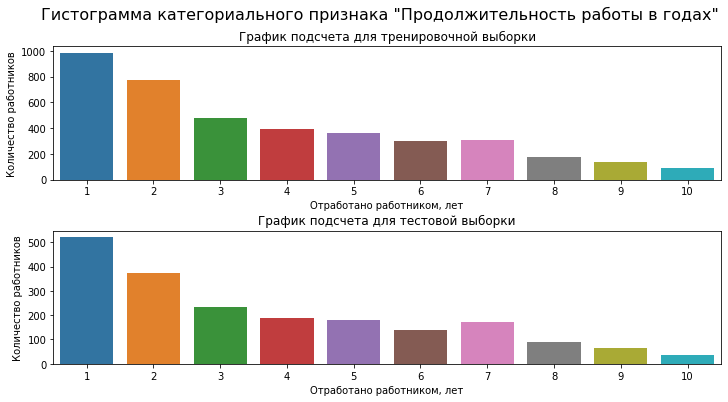

In [76]:
f_countplot(
    train=train_quit['employment_years'],
    test=test_quit['employment_years'],
    suptitle = 'Гистограмма категориального признака "Продолжительность работы в годах"',
    xlabel='Отработано работником, лет',
    ylabel='Количество работников'
)

Исследование `supervisor_evaluation`.

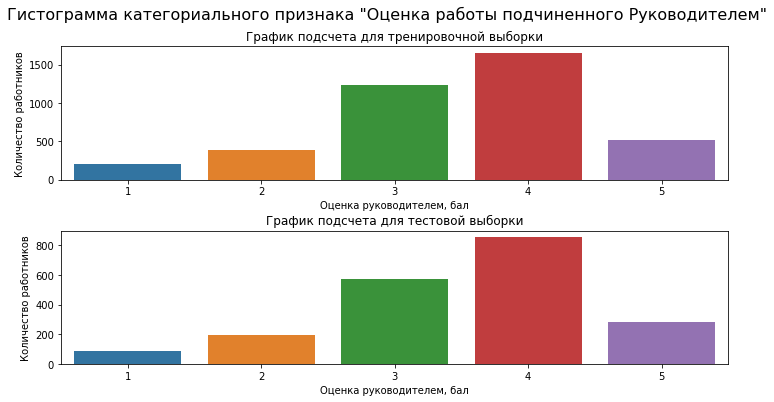

In [77]:
f_countplot(
    train=train_quit['supervisor_evaluation'],
    test=test_quit['supervisor_evaluation'],
    suptitle = 'Гистограмма категориального признака "Оценка работы подчиненного Руководителем"',
    xlabel='Оценка руководителем, бал',
    ylabel='Количество работников'
)

Исследование `salary`.

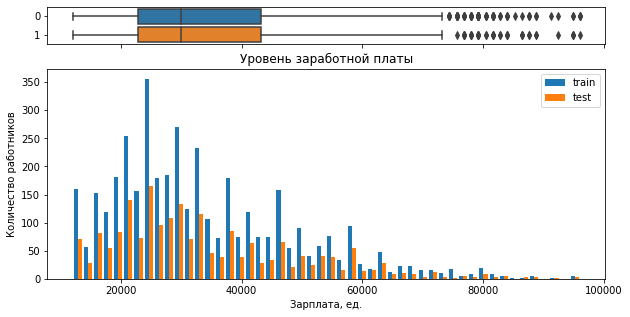

In [78]:
f_hist_box(
    train=train_quit['salary'],
    test=test_quit['salary'],
    bins=50,
    range=(train_quit['salary'].min(),train_quit['salary'].max()),
    title='Уровень заработной платы',
    xlabel='Зарплата, ед.',
    ylabel='Количество работников'
)

### Категориальные данные

Рассмотрим категориальные данные.

In [79]:
train_quit.describe(include='object')

,dept,level,workload,last_year_promo,last_year_violations,quit
count,4000,4000,4000,4000,4000,4000
unique,5,3,3,2,2,2
top,sales,junior,medium,no,no,no
freq,1438,1949,2118,3887,3455,2872


In [80]:
test_quit.describe(include='object')

,dept,level,workload,last_year_promo,last_year_violations,quit
count,1998,1999,2000,2000,2000,2000
unique,6,3,4,2,2,2
top,sales,junior,medium,no,no,no
freq,763,974,1043,1937,1738,1436


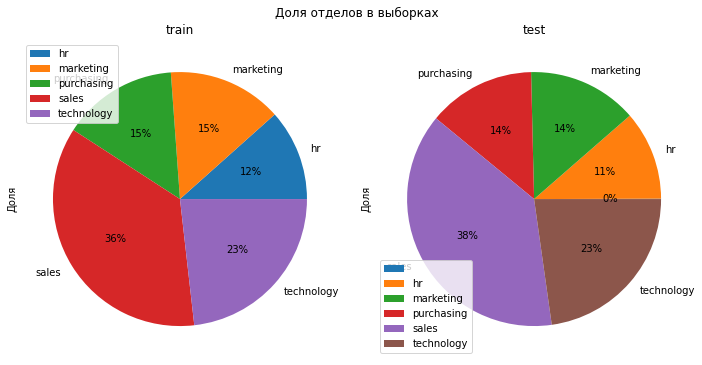

In [81]:
f_pie_x2(train=train_quit,
         test=test_quit,
         col='dept',
         suptitle='Доля отделов в выборках'
)

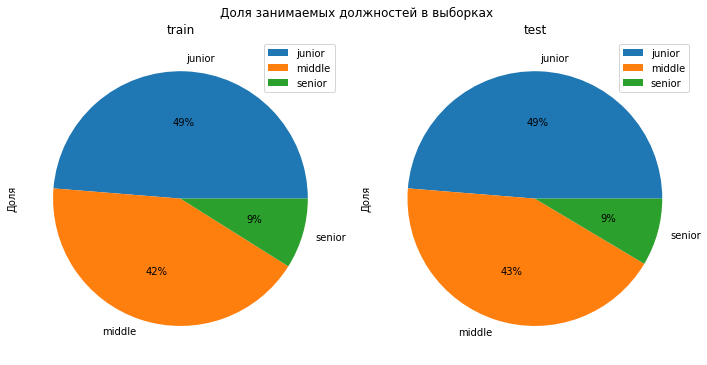

In [82]:
f_pie_x2(train=train_quit,
         test=test_quit,
         col='level',
         suptitle='Доля занимаемых должностей в выборках'
)

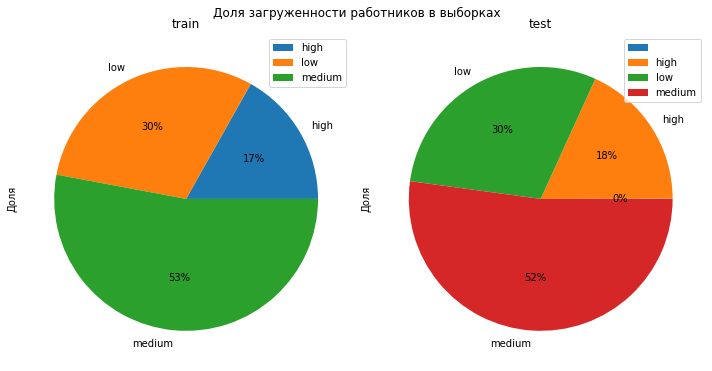

In [83]:
f_pie_x2(train=train_quit,
         test=test_quit,
         col='workload',
         suptitle='Доля загруженности работников в выборках'
)

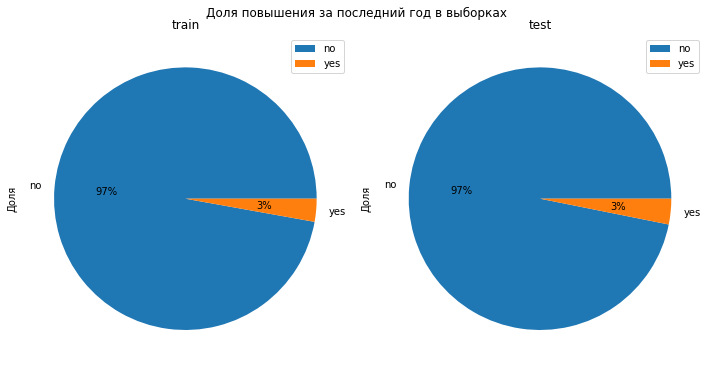

In [84]:
f_pie_x2(train=train_quit,
         test=test_quit,
         col='last_year_promo',
         suptitle='Доля повышения за последний год в выборках'
)

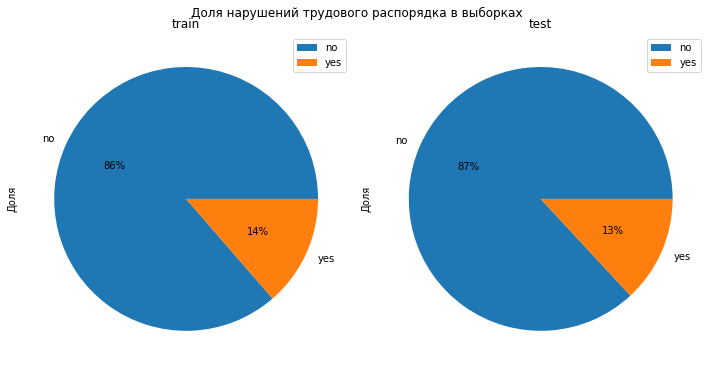

In [85]:
f_pie_x2(train=train_quit,
         test=test_quit,
         col='last_year_violations',
         suptitle='Доля нарушений трудового распорядка в выборках'
)

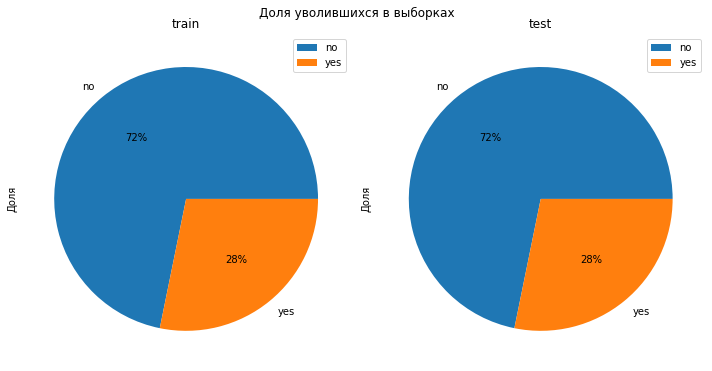

In [86]:
f_pie_x2(train=train_quit,
         test=test_quit,
         col='quit',
         suptitle='Доля уволившихся в выборках'
)

### Портрет уволившегося сотрудника

In [87]:
# fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 5))
# fig.suptitle('Диаграммы портрета уволившегося сотрудника', x=0.5, y=0.99, fontsize=12)

# (
# train_quit.query('quit == "yes"') 
# .pivot_table(index='employment_years',values='id',aggfunc='count')
# .plot.bar(y='id', #autopct='%1.0f%%',
#           figsize=(10,10), ax=axes[0,0], 
# label='Доля')
# )
# (
# train_quit.query('quit == "yes"') 
# .pivot_table(index='level',values='id',aggfunc='count')
# .plot.pie(y='id', autopct='%1.0f%%', figsize=(10,10), ax=axes[0,1], 
# label='Доля', legend=False)
# )
# (
# train_quit.query('quit == "yes"') 
# .pivot_table(index='supervisor_evaluation',values='id',aggfunc='count')
# .plot.bar(y='id', #autopct='%1.0f%%',
#           figsize=(10,10), ax=axes[1,0], 
# label='Доля', legend=False)
# )
# (
# train_quit.query('quit == "yes"') 
# .pivot_table(index='dept',values='id',aggfunc='count')
# .plot.pie(y='id', autopct='%1.0f%%', figsize=(10,10), ax=axes[1,1], 
# label='Доля', legend=False)
# )
# (
# train_quit.query('quit == "yes"') 
# .pivot_table(index='workload',values='id',aggfunc='count')
# .plot.pie(y='id', autopct='%1.0f%%', figsize=(10,10), ax=axes[2,0], 
# label='Доля', legend=False)
# )
# (
# train_quit.query('quit == "yes"') 
# .pivot_table(index='last_year_violations',values='id',aggfunc='count')
# .plot.pie(y='id', autopct='%1.0f%%', figsize=(10,10), ax=axes[2,1], 
# label='Доля', legend=False)
# )

# axes[0,0].set_title('График работы по годам')
# axes[0,1].set_title('Диаграмма навыков')
# axes[1,0].set_title('Диаграмма оценки руководителем')
# axes[1,1].set_title('Диаграмма работы в отделе')
# axes[2,0].set_title('Диаграмма загруженности')
# axes[2,1].set_title('Диаграмма нарушения трудовой дисциплины')
# plt.tight_layout()
# plt.show()

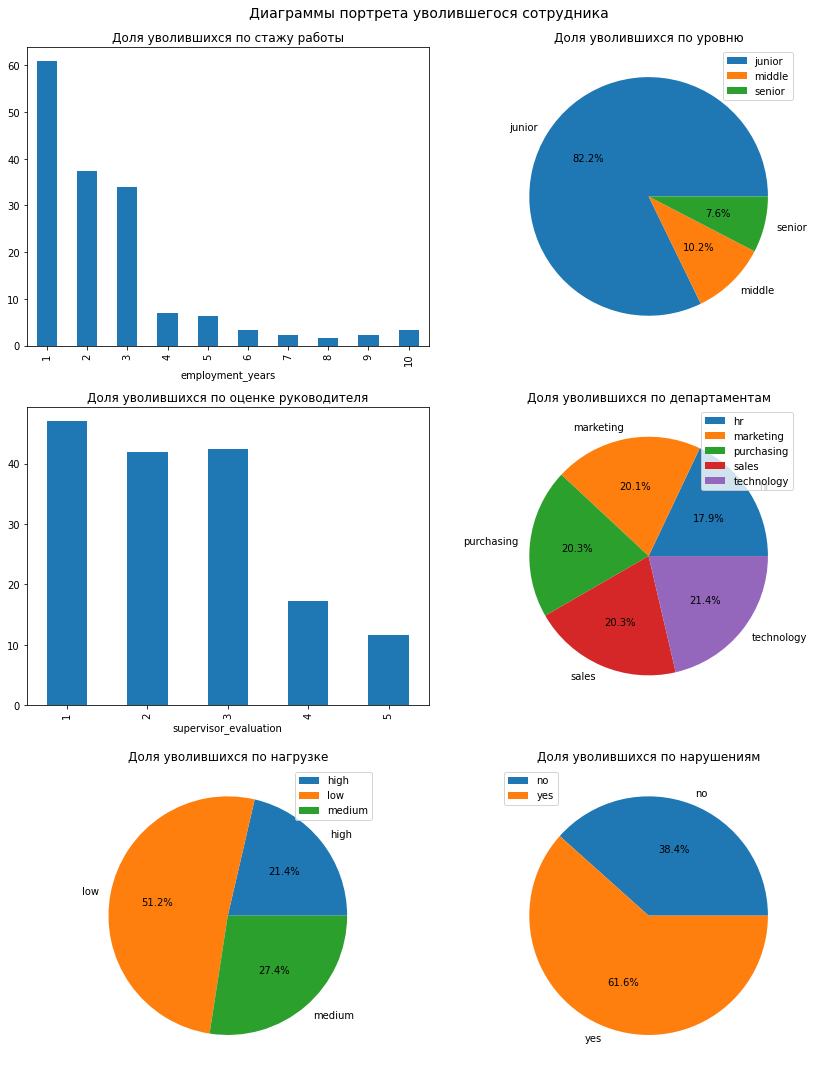

In [88]:
# Функция для расчета доли уволившихся
def calculate_quit_ratio(data, column):
    return (
        data.groupby(column)['quit']
        .value_counts(normalize=True)
        .mul(100)
        .rename('Доля (%)')
        .reset_index()
        .query('quit == "yes"')
    )

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 15))
fig.suptitle('Диаграммы портрета уволившегося сотрудника', fontsize=14, y=0.99)

quit_ratio_emp_years = calculate_quit_ratio(train_quit, 'employment_years')
quit_ratio_emp_years.plot.bar(x='employment_years', y='Доля (%)', ax=axes[0,0], legend=False)
axes[0,0].set_title('Количество уволившихся по стажу работы')

quit_ratio_level = calculate_quit_ratio(train_quit, 'level')
quit_ratio_level.plot.pie(y='Доля (%)', labels=quit_ratio_level['level'], autopct='%1.1f%%', ax=axes[0,1])
axes[0,1].set_title('Доля уволившихся по уровню')

quit_ratio_eval = calculate_quit_ratio(train_quit, 'supervisor_evaluation')
quit_ratio_eval.plot.bar(x='supervisor_evaluation', y='Доля (%)', ax=axes[1,0], legend=False)
axes[1,0].set_title('Количество уволившихся по оценке руководителя')

quit_ratio_dept = calculate_quit_ratio(train_quit, 'dept')
quit_ratio_dept.plot.pie(y='Доля (%)', labels=quit_ratio_dept['dept'], autopct='%1.1f%%', ax=axes[1,1])
axes[1,1].set_title('Доля уволившихся по департаментам')

quit_ratio_workload = calculate_quit_ratio(train_quit, 'workload')
quit_ratio_workload.plot.pie(y='Доля (%)', labels=quit_ratio_workload['workload'], autopct='%1.1f%%', ax=axes[2,0])
axes[2,0].set_title('Доля уволившихся по нагрузке')

quit_ratio_violations = calculate_quit_ratio(train_quit, 'last_year_violations')
quit_ratio_violations.plot.pie(y='Доля (%)', labels=quit_ratio_violations['last_year_violations'], autopct='%1.1f%%', ax=axes[2,1])
axes[2,1].set_title('Доля уволившихся по нарушениям')

for ax in axes.flatten():
    ax.set_ylabel('')  # Убираем подпись оси y

plt.tight_layout()
plt.show()

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> ~~Распределение категорий в данных неравномерное, поэтому нужно нормализовать количество ушедших относительно исследуемого признака, Например из какого департамента уходят чаще, оносительно количества работающих в департаменте.\
Сделать это можно сгруппировав данные по признаку и посчитать долю таргета в каждом из значений~~ (`.groupby(['dept'])['quit'].value_counts(normalize=True)`)</font>

</span><br><span style="color: purple; font-weight: bold">Код исправлен, проведена нормализация количества ушедших относительно исследуемых признаков.</span>
    
Вывод по графикам после нормализации относительно исследуемого признака:
+ Веротяно, отработал всего год
+ Навыки работы - junior с вероятностью 82%.
+ Оценен руководителем на 1, 2 или 3 с большой вероятностью.
+ Может являться сотрудником любого из отделов, они равномерно распределены
+ Загрузка сотрудника Low с вероятностью 51% и Medium - 27%.
+ В течении года нарушал трудовую дисциплину с вероятностью 61.6%

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

In [89]:
train_quit.pivot_table(index = 'quit', values = 'salary', aggfunc = 'median')

,salary
quit,
no,34800
yes,22800


### Промежуточный вывод по портрету уволившегося сотрудника
+ Веротяно, отработал всего год
+ Навыки работы - junior с вероятностью 82%.
+ Оценен руководителем на 1, 2 или 3 с большой вероятностью.
+ Может являться сотрудником любого из отделов, они равномерно распределены
+ Загрузка сотрудника Low с вероятностью 51% и Medium - 27%.
+ В течении года нарушал трудовую дисциплину с вероятностью 61.6%
+ Медианная заработная плата составляет 22800, в то время как продолживших работать 34800.

### Влияние уровеня удовлетворённости сотрудника работой на его увольнение

Объединим данные по `id`.

In [90]:
quit_satisfaction = pd.merge(test_target_quit, test_target_job_satisfaction_rate, on='id', sort=True).sort_values(by='id')

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

Построим `гистограмму` и `boxplot`.

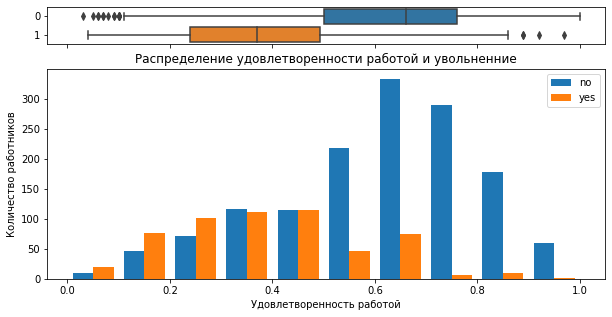

In [91]:
col = 'job_satisfaction_rate'
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, figsize=(10,5), gridspec_kw={"height_ratios": (.15, .85)})
 
sns.boxplot(data=[quit_satisfaction[quit_satisfaction['quit']=='no'][col],
                  quit_satisfaction[quit_satisfaction['quit']=='yes'][col]], orient="h", ax=ax_box)
plt.hist([quit_satisfaction[quit_satisfaction['quit']=='no'][col],
          quit_satisfaction[quit_satisfaction['quit']=='yes'][col]], 
         bins=10, range=(0,1), label=['no', 'yes'])

plt.legend(loc='upper right')
plt.title('Распределение удовлетворенности работой и увольненние')
plt.xlabel('Удовлетворенность работой')
plt.ylabel('Количество работников')
plt.show()

Построим Плотность распределения (KDE) коэффициента удовлетворенности работой.

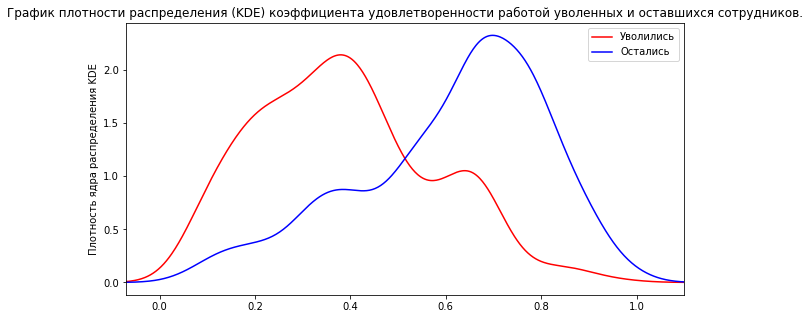

In [92]:
plt.figure(figsize=(10,5))
plt.title('График плотности распределения (KDE) коэффициента удовлетворенности работой уволенных и оставшихся сотрудников.')
plt.xlim (quit_satisfaction['job_satisfaction_rate'].min()-0.1, quit_satisfaction['job_satisfaction_rate'].max()+0.1)
ax = quit_satisfaction[quit_satisfaction['quit']=='yes']['job_satisfaction_rate'].plot.kde(color='red', label='Уволились')
ax = quit_satisfaction[quit_satisfaction['quit']=='no']['job_satisfaction_rate'].plot.kde(color='blue', label='Остались')
ax.set_ylabel('Плотность ядра распределения KDE')
plt.legend() 
plt.show()

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Промежуточный вывод
По графику, гистограмме и боксплоту можно выдвинуть гипотезу о том, что признаки взаимосвязаны. Мы видим, что у уволившихся сотрудников ниже удовлетворенность работой.

Выдвенем гипотезы:

- **H0**: Средние значения совокупной выборки равны, а значит зависимости между увольнением и удовлетворенностью работой нет.\
- **H1**: Средние значения совокупной выборки не равны, а значит есть зависимости между увольнением и удовлетворенностью работой.

In [93]:
group1 = quit_satisfaction[quit_satisfaction['quit']=='yes']
group2 = quit_satisfaction[quit_satisfaction['quit']=='no']

print(ttest_ind(group1['job_satisfaction_rate'], group2['job_satisfaction_rate']))

print(ttest_ind(group1['job_satisfaction_rate'], group2['job_satisfaction_rate'], equal_var= False ))

Ttest_indResult(statistic=-23.074784903634534, pvalue=1.231122066517193e-104)
Ttest_indResult(statistic=-23.795097591114747, pvalue=2.7708628031539788e-101)


Поскольку p-значение меньше 0,05, мы отклоняем нулевую гипотезу t-критерия и делаем вывод, что средние значения генеральной совокупности не равны, значит есть зависимость между увольнением и неудовлетворенностью работой.

### Добавление нового входного признака

Добавим `job_satisfaction_rate`, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.

In [94]:
train_quit['job_satisfaction_rate'] = rs.predict(train_quit)
test_quit['job_satisfaction_rate'] = rs.predict(test_quit)
train_quit.info(), test_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   4000 non-null   object 
 2   level                  4000 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   quit                   4000 non-null   object 
 10  job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 343.9+ KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dt

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:227: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


(None, None)

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Отлично, что добавляется предсказание предыдущей модели.</font>

Дополнение таблиц новыми данными прошло успешно, пропуски в новых данных отсутствуют, проверим корреляционную взаимосвязь данных.


### Корреляционный анализ

Назначим индексом столбец `id`.

In [95]:
train_quit = train_quit.sort_values(by=['id']).set_index('id')
test_quit = test_quit.sort_values(by=['id']).set_index('id')

Для начала создадим список interval_cols, который содержит названия столбцов с непрерывными числовыми признаками.Для начала создадим список interval_cols, который содержит названия столбцов с непрерывными числовыми признаками.

In [96]:
interval_cols = ['salary', 'job_satisfaction_rate']

Построим матрицы корреляций для тренировочной и тестовой выборок.

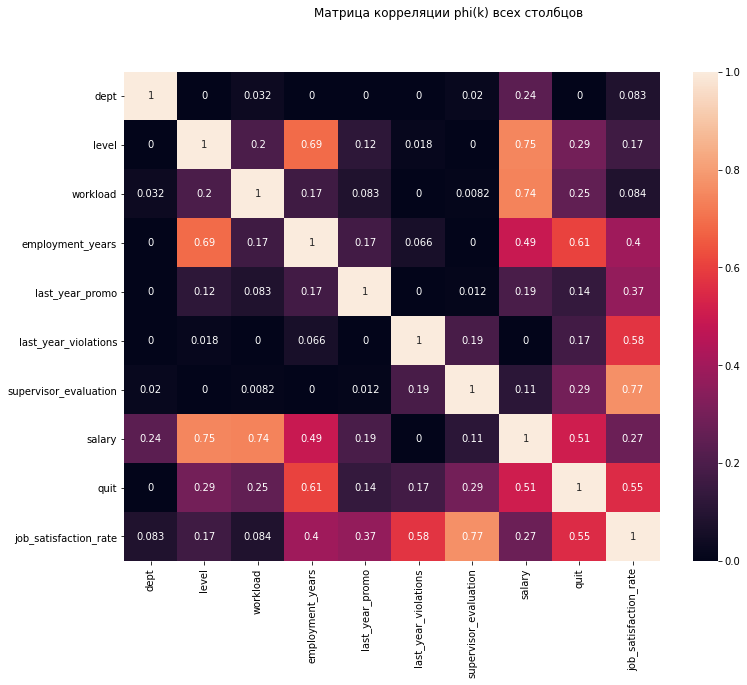

In [97]:
fig, ax = plt.subplots(figsize=(12, 9))
plt.suptitle('Матрица корреляции phi(k) всех столбцов')
sns.heatmap(test_quit.phik_matrix(interval_cols=interval_cols), annot=True);

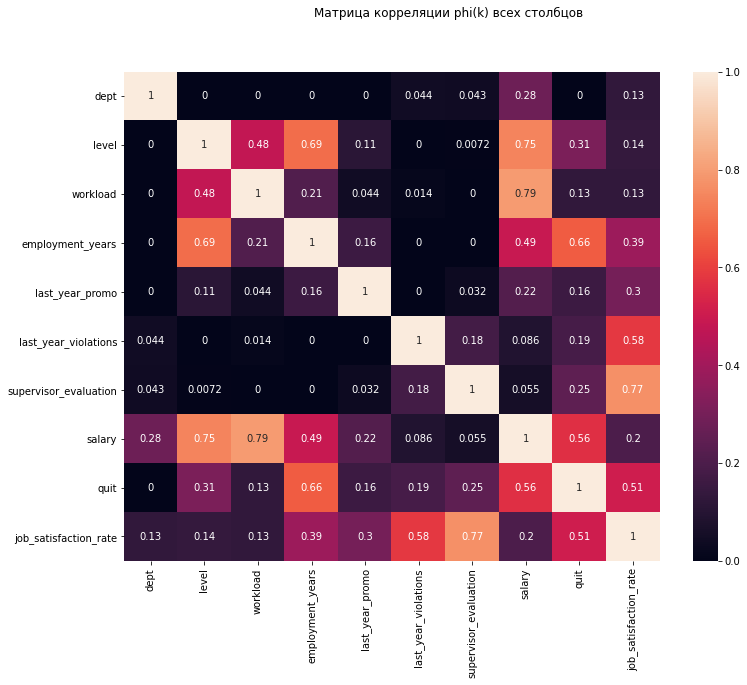

In [98]:
fig, ax = plt.subplots(figsize=(12, 9))
plt.suptitle('Матрица корреляции phi(k) всех столбцов')
sns.heatmap(train_quit.phik_matrix(interval_cols=interval_cols), annot=True);

### Вывод по добавлению нового входного признака и матрице корреляций
+ Данные `id`, переведены в индекс, отсортированы по возрастающей.
+ Отсутствует связь выше 0.9, следовательно учитывать мультиколлинеарность не надо.
+ На тренировочной и тестовой выборках, значения корреляции немного разнятся, но общая оценка соответствуют друг другу.
+ Был получен портет уволившегося сотрудника:
    - Отработал всего год в половине случаев.
    - Навыки работы - junior с вероятностью 89%.
    - Оценен руководителем на 3 по 5-ти бальной шкале с вероятностью 46%.
    - Является сотрудником отдела Sales с вероятностью 36%, отдела Technology - 24%.
    - Загрузка сотрудника Low с вероятностью 46% и Medium - 43%.
    - В течении года нарушал трудовую дисциплину с вероятностью 20%
    - Медианная заработная плата составляет 22800, в то время как продолживших работать 34800.
+ Была исследована взаимосвязь между увольнением и неудовлетворенностью сотрудника работой.
+ К исходным данным добавлен уровень удовлетворенности работой `job_satisfaction_rate` полученный на основе лучшей модели.
+ В колонках `dept`, `level`, `workload` необходимо заменить пропуски.
+ Три признака: `dept`, `last_year_promo`, `last_year_violations` — нужно кодировать с помощью OneHotEncoder.
+ Два признака: `level`, `workload` — нужно кодировать с помощью OrdinalEncoder.
+ Четыре признака: `employment_years`, `supervisor_evaluation`, `salary`, `job_satisfaction_rate`- достаточно масштабировать.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## Подготовка данных

Отличия: В подготовке данных к обучению модели добавляется признак `job_satisfaction_rate`, который содержит числовые значения и подлежит масштабированию.

Воспользуемся LabelEncoder для кодирования целевых признаков

In [99]:
le = LabelEncoder()
le.fit_transform(train_quit['quit'].unique())
print ('Значениям', le.classes_, 'назначено соответственно', le.transform(le.classes_))
train_quit['quit'] = le.transform(train_quit['quit'])
test_quit['quit'] = le.transform(test_quit['quit'])

Значениям ['no' 'yes'] назначено соответственно [0 1]


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [100]:
X_train_2 = train_quit.drop('quit', axis=1)
y_train_2 = train_quit['quit'] 
X_test_2 = test_quit.drop('quit', axis=1)
y_test_2 = test_quit['quit']

num_columns = ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

Переопределим `data_preprocessor`.

In [101]:
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', RobustScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [102]:
X_train_2_transformed = pd.DataFrame(data_preprocessor.fit_transform(X_train_2), columns=data_preprocessor.get_feature_names_out())
X_test_2_transformed = pd.DataFrame(data_preprocessor.transform(X_test_2), columns=data_preprocessor.get_feature_names_out())

X_train_2_transformed.info(), X_test_2_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ohe__dept_marketing            4000 non-null   float64
 1   ohe__dept_purchasing           4000 non-null   float64
 2   ohe__dept_sales                4000 non-null   float64
 3   ohe__dept_technology           4000 non-null   float64
 4   ohe__last_year_promo_yes       4000 non-null   float64
 5   ohe__last_year_violations_yes  4000 non-null   float64
 6   ord__level                     4000 non-null   float64
 7   ord__workload                  4000 non-null   float64
 8   num__employment_years          4000 non-null   float64
 9   num__supervisor_evaluation     4000 non-null   float64
 10  num__salary                    4000 non-null   float64
 11  num__job_satisfaction_rate     4000 non-null   float64
dtypes: float64(12)
memory usage: 375.1 KB
<class 'pa

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:227: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


(None, None)


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ⚠️\
<span style="color: darkorange"> Это зачем?</span>

In [103]:
X_train_2_transformed.head()

,ohe__dept_marketing,ohe__dept_purchasing,ohe__dept_sales,ohe__dept_technology,ohe__last_year_promo_yes,ohe__last_year_violations_yes,ord__level,ord__workload,num__employment_years,num__supervisor_evaluation,num__salary,num__job_satisfaction_rate
0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,-2.00,-0.47,-0.60
1,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,-1.00,-0.41,-0.59
2,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,-0.50,0.00,-0.06,0.27
3,0.00,0.00,0.00,1.00,0.00,0.00,1.00,2.00,0.25,0.00,1.88,0.39
4,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,-0.25,0.00,-0.24,0.84


### Вывод по подготовке данных
Воспользовались двумя кодировщиками, вывели информацию о процессе кодирования.

## Обучение модели

Поиск лучшей модели перебором всех моделей и их параметров.

In [104]:
# Создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', SVC(random_state=RANDOM_STATE, probability=True))
])

param_grid = [
    # Словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__criterion': ['gini', 'entropy', 'log_loss'],
        'models__splitter': ['best', 'random'],
        'models__max_depth': [None] + [i for i in range(2, 7)], #range(1, 700),
        'models__min_samples_split': range(2, 10),
        'models__min_samples_leaf': range(2, 10),
        'models__max_leaf_nodes': range(1, 270),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
                                   
    # Словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']   
    },

    # Словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    },
    
    # Словарь для модели SVC()
    {
        'models': [SVC(random_state=RANDOM_STATE, probability=True)],
        'models__kernel': ['poly', 'rbf', 'sigmoid'],
        'models__degree': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    }
]

rs = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rs.fit(X_train_2, y_train_2)

print('Лучшая модель и её параметры:\n\n', rs.best_estimator_)
print ('Метрика лучшей модели на на кросс-валидации:', rs.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                   

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

Отберем модель по лучшим показателям на кросс-валидации.

In [105]:
all_model_2 = pd.DataFrame(rs.cv_results_).sort_values(by=['rank_test_score'])
all_model_2[['rank_test_score', 'mean_test_score', 'param_models', 'params']].head(10)         

,rank_test_score,mean_test_score,param_models,params
2,1,0.93,"DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30,\n min_samples_leaf=3, min_samples_split=7,\n random_state=42)","{'preprocessor__num': RobustScaler(), 'models__splitter': 'best', 'models__min_samples_split': 7, 'models__min_samples_leaf': 3, 'models__max_leaf_nodes': 30, 'models__max_depth': 6, 'models__criterion': 'log_loss', 'models': DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30, min_samples_leaf=3, min_samples_split=7, random_state=42)}"
6,2,0.93,"DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30,\n min_samples_leaf=3, min_samples_split=7,\n random_state=42)","{'preprocessor__num': MinMaxScaler(), 'models__splitter': 'best', 'models__min_samples_split': 9, 'models__min_samples_leaf': 3, 'models__max_leaf_nodes': 61, 'models__max_depth': 5, 'models__criterion': 'log_loss', 'models': DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30, min_samples_leaf=3, min_samples_split=7, random_state=42)}"
5,3,0.92,"DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30,\n min_samples_leaf=3, min_samples_split=7,\n random_state=42)","{'preprocessor__num': StandardScaler(), 'models__splitter': 'random', 'models__min_samples_split': 4, 'models__min_samples_leaf': 2, 'models__max_leaf_nodes': 86, 'models__max_depth': 6, 'models__criterion': 'gini', 'models': DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30, min_samples_leaf=3, min_samples_split=7, random_state=42)}"
3,4,0.92,"DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30,\n min_samples_leaf=3, min_samples_split=7,\n random_state=42)","{'preprocessor__num': 'passthrough', 'models__splitter': 'random', 'models__min_samples_split': 2, 'models__min_samples_leaf': 3, 'models__max_leaf_nodes': 79, 'models__max_depth': None, 'models__criterion': 'log_loss', 'models': DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30, min_samples_leaf=3, min_samples_split=7, random_state=42)}"
7,5,0.92,"DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30,\n min_samples_leaf=3, min_samples_split=7,\n random_state=42)","{'preprocessor__num': RobustScaler(), 'models__splitter': 'random', 'models__min_samples_split': 4, 'models__min_samples_leaf': 5, 'models__max_leaf_nodes': 108, 'models__max_depth': 6, 'models__criterion': 'entropy', 'models': DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30, min_samples_leaf=3, min_samples_split=7, random_state=42)}"
0,6,0.92,"DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30,\n min_samples_leaf=3, min_samples_split=7,\n random_state=42)","{'preprocessor__num': RobustScaler(), 'models__splitter': 'random', 'models__min_samples_split': 6, 'models__min_samples_leaf': 3, 'models__max_leaf_nodes': 31, 'models__max_depth': 5, 'models__criterion': 'log_loss', 'models': DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30, min_samples_leaf=3, min_samples_split=7, random_state=42)}"
1,7,0.92,"DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30,\n min_samples_leaf=3, min_samples_split=7,\n random_state=42)","{'preprocessor__num': StandardScaler(), 'models__splitter': 'random', 'models__min_samples_split': 5, 'models__min_samples_leaf': 7, 'models__max_leaf_nodes': 50, 'models__max_depth': 5, 'models__criterion': 'log_loss', 'models': DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30, min_samples_leaf=3, min_samples_split=7, random_state=42)}"
4,8,0.91,"DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30,\n min_samples_leaf=3, min_samples_split=7,\n random_state=42)","{'preprocessor__num': StandardScaler(), 'models__splitter': 'random', 'models__min_samples_split': 9, 'models__min_samples_leaf': 4, 'models__max_leaf_nodes': 216, 'models__max_depth': N

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> ~~Нужно вывести результаты оценки Топ-10 лучших моделей, для анализа.~~</font>

</span><br><span style="color: purple; font-weight: bold">Вывел топ 10 лучших моделей. Все из них это DecisionTreeClassifier с разными параметрами.</span>

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

Оценим вклад признаков для `DecisionTreeClassifier`.

In [106]:
# best_model = rs.best_estimator_

# # Преобразование данных
# X_transformed = pd.DataFrame(
#     data_preprocessor.transform(X_test_2),
#     columns=data_preprocessor.get_feature_names_out()
# )

# # Вычисление SHAP-значений для одного наблюдения
# explainer = shap.TreeExplainer(best_model.named_steps['models'])
# shap_values = explainer(X_transformed.iloc[[0]])  # Первый образец

# # Визуализация
# plt.figure(figsize=(10, 6))
# shap.plots.waterfall(
#     shap_values[0, :, 1],  # Для положительного класса (бинарная классификация)
#     max_display=20,
#     show=False
# )

# # Настройка отображения
# ax = plt.gca()
# ax.set_title('Влияние признаков на прогноз (Waterfall)', fontsize=14)
# ax.set_xlabel('Вклад признака в SHAP-значение', fontsize=10)
# ax.set_ylabel('Признаки', fontsize=10)

# # Уменьшаем размер шрифта для длинных названий
# ax.tick_params(axis='y', labelsize=8)

# # Убираем лишние элементы
# plt.subplots_adjust(left=0.3)  # Регулируем отступ для названий признаков
# plt.show()

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:227: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


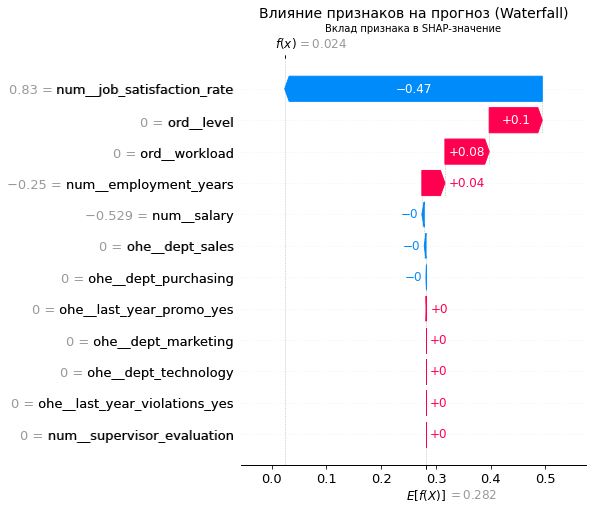

In [107]:
best_model = rs.best_estimator_

# Извлекаем препроцессор из лучшей модели
preprocessor = best_model.named_steps['preprocessor']  # Убедитесь, что имя шага совпадает с вашим пайплайном

# Преобразование данных с использованием препроцессора из модели
X_transformed = pd.DataFrame(
    preprocessor.transform(X_test_2),  # Используем препроцессор из best_model
    columns=preprocessor.get_feature_names_out()
)

# Вычисление SHAP-значений для одного наблюдения
explainer = shap.TreeExplainer(best_model.named_steps['models'])
shap_values = explainer(X_transformed.iloc[[0]])

# Визуализация
plt.figure(figsize=(10, 6))
shap.plots.waterfall(
    shap_values[0, :, 1],
    max_display=20,
    show=False
)
# Настройка отображения
ax = plt.gca()
ax.set_title('Влияние признаков на прогноз (Waterfall)', fontsize=14)
ax.set_xlabel('Вклад признака в SHAP-значение', fontsize=10)
ax.set_ylabel('Признаки', fontsize=10)

# Уменьшаем размер шрифта для длинных названий
ax.tick_params(axis='y', labelsize=8)

# Убираем лишние элементы
plt.subplots_adjust(left=0.3)  # Регулируем отступ для названий признаков
plt.show()

<font color='blue'><b>Комментарий ревьюера : </b></font> ❌\
<font color='red'> ~~Препроцессор нужно то же взять из Лучшей модели, выбранной выше~~ (`rs.best_estimator_`)</font>

</span><br><span style="color: purple; font-weight: bold">Взял препроцессор от лучшей модели и повторил код.</span>

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

Проверим лучшую модель на соответствие условию: ROC-AUC ≥ 0.91 на тестовой выборке.

In [108]:
roc_auc_rs_test = roc_auc_score(y_test_2, rs.predict_proba(X_test_2)[:, 1])
if (roc_auc_rs_test >= 0.91):
    print ('Модель удовлетворяет условию: на тестовой выборке ROC-AUC', round(roc_auc_rs_test, 4), '>= 0.91')
else:
    print('Модель не удовлетворяет условию:  ROC-AUC на тестовой выборке >= 0.91 n\ ТРЕБУЕТСЯ ДОПОЛНИТЕЛЬНОЕ ИССЛЕДОВАНИЕ')

Модель удовлетворяет условию: на тестовой выборке ROC-AUC 0.9286 >= 0.91


/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:227: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

Отобранная модель соответствует условию.

In [109]:
dummy_class = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_class.fit(X_train_2, y_train_2)

roc_auc_rs_train = roc_auc_score(y_train_2, rs.predict_proba(X_train_2)[:, 1])
print(f'Значение ROC-AUC лучшей модели на тренировочной выборке: {round(roc_auc_rs_train, 4)}')
roc_auc_rs_train = roc_auc_score(y_train_2, dummy_class.predict_proba(X_train_2)[:, 1])
print(f'Значение ROC-AUC модели `DummyClassifier` на тренировочной выборке: {round(roc_auc_rs_train, 4)}')
print('-------------------------------')
roc_auc_rs_test = roc_auc_score(y_test_2, rs.predict_proba(X_test_2)[:, 1])
print(f'Значение ROC-AUC лучшей модели на тестовой выборке: {round(roc_auc_rs_test, 4)}')
roc_auc_rs_test = roc_auc_score(y_test_2, dummy_class.predict_proba(X_test_2)[:, 1])
print(f'Значение ROC-AUC модели `DummyClassifier` на тестовой выборке: {round(roc_auc_rs_test, 4)}')

Значение ROC-AUC лучшей модели на тренировочной выборке: 0.9498
Значение ROC-AUC модели `DummyClassifier` на тренировочной выборке: 0.4975
-------------------------------
Значение ROC-AUC лучшей модели на тестовой выборке: 0.9286
Значение ROC-AUC модели `DummyClassifier` на тестовой выборке: 0.4999


/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:227: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ⚠️\
<span style="color: darkorange">ROC-AUC константной модели всегда 0.5 - можно и не смотреть 😊</span> 

## Выводы

Лучшая модель:`DecisionTreeClassifier(criterion='log_loss', max_depth=6, max_leaf_nodes=30, min_samples_leaf=3, min_samples_split=7, random_state=42)` На тестовой выборке модель дала значение ROC_AUC  в 0.9286

Данная модель лучше справилась с прогнозированием, так как при её построении было перебрано больше параметров и на неё меньше оказывают влияния существующие выбросы в данных.

Оценено влияние признаков на прогноз:
- Наибольшее отрицательное влияние оказывает удовлетворенность работой.
- Уровень навыков сотрудника влияет положительно.
- Уровень нагрузки влияет положительно.

Модель была проверена на адекватность, её качество по метрике ROC-AUC значительно превосходит метрику модели `DummyClassifier`
- Значение ROC-AUC лучшей модели на обучающей выборке: 0.9498
- Значение ROC-AUC модели `DummyClassifier` на обучающей выборке: 0.4975

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

# Общий вывод

**Итоговый вывод по проекту**  

**Общие результаты**  
1. **Качество данных**:  
   - Отсутствуют дубликаты и критичные ошибки в типах данных.  
   - Пропуски обработаны через `SimpleImputer` в пайплайне.  
   - Распределения признаков в тестовой и обучающей выборках согласованы, что подтверждает репрезентативность данных.  

2. **Корреляционный анализ**:  
   - Отсутствует мультиколлинеарность (максимальная корреляция < 0.9).  
   - Выявлены наиболее коррелирующие признаки: уровень навыков, зарплата, стаж, удовлетворённость работой.  

3. **Подготовка данных**:  
   - Категориальные признаки закодированы (`OneHotEncoder`, `OrdinalEncoder`).  
   - Числовые признаки масштабированы (`MinMaxScaler`, `RobustScaler`).  

**Результаты по задачам**  

**Задача 1: Прогнозирование удовлетворённости работой**  
- **Лучшая модель**: `DecisionTreeRegressor` с параметрами:  
  - `max_features=9`, `max_depth=None`, масштабирование `MinMaxScaler`.  
- **Качество**:  
  - SMAPE на тесте: **14.9** (соответствует целевому критерию ≤15).  
  - Значительно превосходит `DummyRegressor`, что подтверждает адекватность.  
- **Интерпретация**:  
  - Отсутствие линейной связи между признаками и целевой переменной обьясняет выбор дерева решений.  

**Задача 2: Прогнозирование увольнения**  
- **Лучшая модель**: `DecisionTreeClassifier` с параметрами:  
  - `criterion='log_loss'`, `max_depth=6`, `max_leaf_nodes=30`, `min_samples_leaf=3`.  
- **Качество**:  
  - ROC-AUC на тесте: **0.9286** (целевой порог ≥0.91 достигнут).  
  - ROC-AUC на обучении: **0.9498** vs. `DummyClassifier`: **0.4975** (разрыв ≈90%).  
- **Ключевые факторы увольнения**:  
  - **Отрицательное влияние**: Низкая удовлетворённость работой (`job_satisfaction_rate`).  
  - **Положительное влияние**: Уровень навыков, загруженность, зарплата.  
- **Портрет увольняющегося сотрудника**:  
  - Стаж ≤1 года, оценка руководителя ≤3, отдел Sales/Technology, зарплата ниже медианной.  

**Практическая значимость**  
1. **Для HR-аналитики**:  
   - Модели позволяют прогнозировать риски оттока и уровень удовлетворённости, что помогает:  
     - Своевременно реагировать на негативные тенденции.  
     - Формировать программы удержания сотрудников (напр., пересмотр зарплат, снижение нагрузки).  
   - Автоматизация снижает зависимость от ручных опросов.  

2. **Рекомендации бизнесу**:  
   - Мониторить сотрудников с стажем <1 года и зарплатой ниже 30 000.  
   - Уделить внимание сотрудникам отделов Sales и Technology.  
   - Использовать уровень удовлетворённости как индикатор риска увольнения.  

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'>Валерий, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
Выводы и рассуждения получились содержательными, их было интересно читать.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>

</span><br><span style="color: purple; font-weight: bold">Проведена работа над ошибками, все критические недочеты устранены.</span>
- Код, в котором была ручная замена пробелов на np.nan закомментирован, обработка этих значений происходит внутри пайплайнов.
- Вывод 10 лучших моделей и анализ списка проведены
- 

<font color='blue'><b>Итоговый комментарий ревьюера 2</b></font>\
<font color='green'> Валерий, проект принят! \
Все этапы пройдены. Все рекомендации учтены.\
Надеюсь, тебе понравился процесс выполнения и результат.</font> \
<font color='blue'><b>Спасибо, удачи в освоении профессии!</b></font>